# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [6]:
#!pip install  scikit-learn

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [9]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [11]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [13]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

We can plot the output, comparing signal and background:

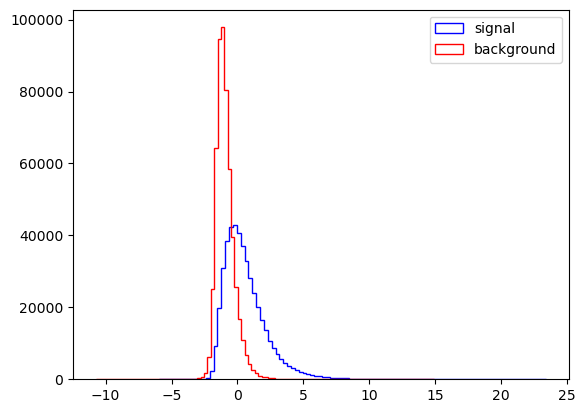

In [15]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

In [17]:
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

def print_scores(fitted_model):
    res = {
        "Accuracy on train:": accuracy_score(fitted_model.predict(X_Train), y_Train),
        "ROC AUC on train:": roc_auc_score(
            y_Train, fitted_model.predict_proba(X_Train)[:, 1]
        ),
        "Accuracy on valid:": accuracy_score(fitted_model.predict(X_Test), y_Test),
        "ROC AUC on valid:": roc_auc_score(
            y_Test, fitted_model.predict_proba(X_Test)[:, 1]
        ),
    }

    if hasattr(fitted_model, "oob_score_"):
        res["OOB accuracy:"] = fitted_model.oob_score_

    for k, v in res.items():
        print(k, round(v, 3))

    #Combined ROC plot
    fig, ax = plt.subplots()
    RocCurveDisplay.from_estimator(fitted_model, X_Train, y_Train, ax=ax, name="Train")
    RocCurveDisplay.from_estimator(fitted_model, X_Test, y_Test, ax=ax, name="Test")
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')  # Dotted baseline
    ax.set_title("ROC Curve: Train vs Test")
    ax.grid(True)
    ax.legend()
    plt.show()

Train Accuracy:  0.7576755
Test Accuracy:  0.757471

=== Confusion Matrix ===
[[493081  48686]
 [193843 264390]]


Accuracy on train: 0.758
ROC AUC on train: 0.836
Accuracy on valid: 0.757
ROC AUC on valid: 0.836


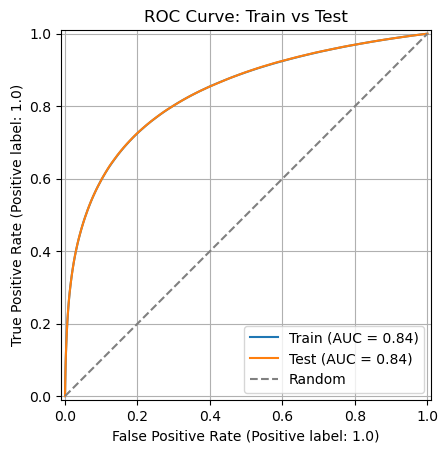

In [18]:
from sklearn.metrics import confusion_matrix

# Evaluating Fisher model
Fisher_predict = Fisher.predict(X_Test)

print("Train Accuracy: ", Fisher.score(X_Train, y_Train))
print("Test Accuracy: ", Fisher.score(X_Test, y_Test))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_Test, Fisher_predict))
print("\n")

# Showing full evaluation and ROC plot
print_scores(Fisher)

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

Raw Feature Names: ['signal', 'l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta', 'l_2_phi', 'MET', 'MET_phi']
Derived Features (not used here): ['R', 'cos_theta_r1', 'S_R', 'MET_rel', 'axial_MET', 'M_TR_2', 'MT2', 'dPhi_r_b', 'M_Delta_R', 'M_R']
Train Accuracy: 0.752018311995422
Test Accuracy: 0.751624

=== Confusion Matrix ===
[[504621  37146]
 [211230 247003]]

Accuracy on train: 0.752
ROC AUC on train: 0.833
Accuracy on valid: 0.752
ROC AUC on valid: 0.833


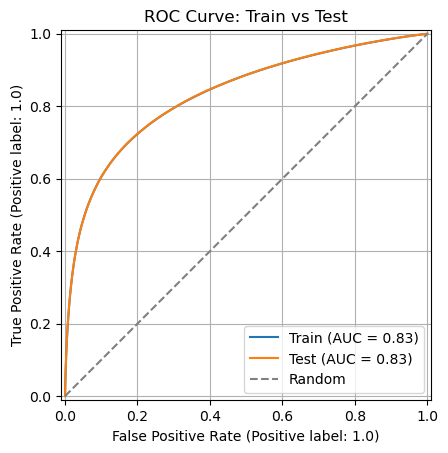

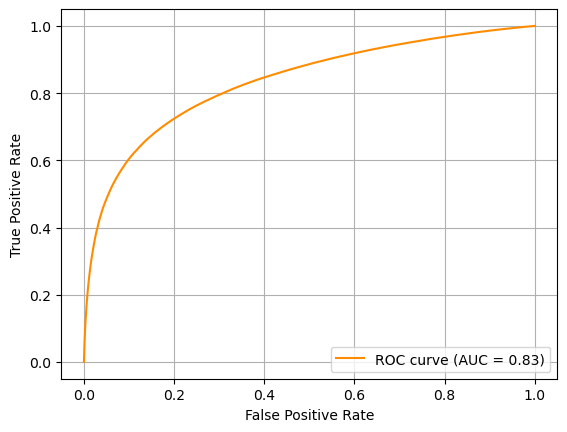

In [20]:
# Using Only Raw Features

RawNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi", 
            "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]

# Derive feature names by subtracting RawNames from all variables
FeatureNames = list(set(VarNames[1:]) - set(RawNames))
print("Raw Feature Names:", RawNames)
print("Derived Features (not used here):", FeatureNames)

# Split training and testing data
N_Train = 4000000
Train_Sample = df.loc[:N_Train, RawNames]
Test_Sample = df.loc[N_Train:, RawNames]

# Define input and output
X_Train = Train_Sample[RawNames[1:]]
y_Train = Train_Sample["signal"]
X_Test = Test_Sample[RawNames[1:]]
y_Test = Test_Sample["signal"]

# Fit LDA model
Fisher.fit(X_Train, y_Train)
Fisher_predict = Fisher.predict(X_Test)

# Accuracy & confusion matrix
print("Train Accuracy:", Fisher.score(X_Train, y_Train))
print("Test Accuracy:", Fisher.score(X_Test, y_Test))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_Test, Fisher_predict))
print()

# Print full scores
print_scores(Fisher)

# ROC Curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Selected Feature Columns: ['R', 'cos_theta_r1', 'S_R', 'MET_rel', 'axial_MET', 'M_TR_2', 'MT2', 'dPhi_r_b', 'M_Delta_R', 'M_R']
Train Accuracy: 0.7494203126449218
Test Accuracy: 0.749761

=== Confusion Matrix ===
[[491460  50307]
 [199932 258301]]

Accuracy on train: 0.749
ROC AUC on train: 0.823
Accuracy on valid: 0.75
ROC AUC on valid: 0.823


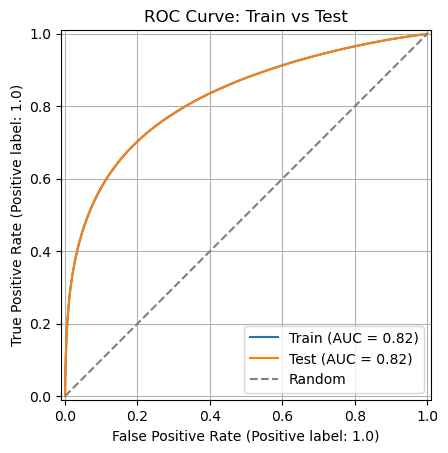

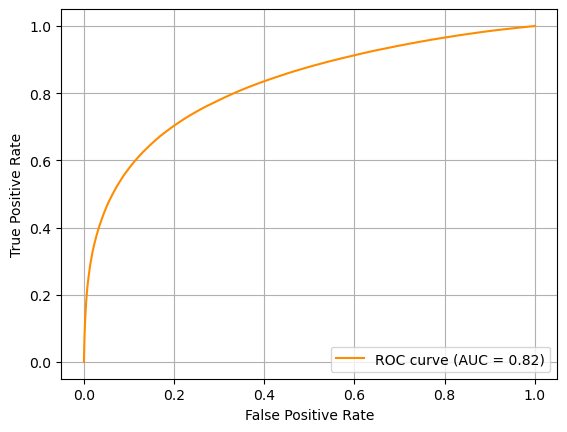

In [21]:
# Using Only Derived Features (no raw kinematic inputs)

# Get only derived features (exclude raw ones)
FeatureNames = ["signal"] + list(set(VarNames[1:]) - set(RawNames))
print("Selected Feature Columns:", FeatureNames[1:])

# Train/Test split using only feature columns
N_Train = 4000000
Train_Sample = df.loc[:N_Train, FeatureNames]
Test_Sample = df.loc[N_Train:, FeatureNames]

# Define input X and target y
X_Train = Train_Sample[FeatureNames[1:]]
y_Train = Train_Sample["signal"]
X_Test = Test_Sample[FeatureNames[1:]]
y_Test = Test_Sample["signal"]

# Optional: for plotting purposes
Test_sig = Test_Sample[Test_Sample.signal == 1]
Test_bkg = Test_Sample[Test_Sample.signal == 0]

# Fit the LDA model
Fisher.fit(X_Train, y_Train)
Fisher_predict = Fisher.predict(X_Test)

# Accuracy and confusion matrix
print("Train Accuracy:", Fisher.score(X_Train, y_Train))
print("Test Accuracy:", Fisher.score(X_Test, y_Test))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_Test, Fisher_predict))
print()

# Evaluation scores
print_scores(Fisher)

# ROC Curve
fpr2, tpr2, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
roc_auc2 = auc(fpr2, tpr2)

plt.plot(fpr2, tpr2, color='darkorange', label=f'ROC curve (AUC = {roc_auc2:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Using Combined Inputs: ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta', 'l_2_phi', 'MET', 'MET_phi', 'R', 'cos_theta_r1', 'S_R', 'MET_rel', 'axial_MET', 'M_TR_2', 'MT2', 'dPhi_r_b', 'M_Delta_R', 'M_R']
Train Accuracy: 0.7576755605811099
Test Accuracy: 0.757471

=== Confusion Matrix ===
[[493081  48686]
 [193843 264390]]

Accuracy on train: 0.758
ROC AUC on train: 0.836
Accuracy on valid: 0.757
ROC AUC on valid: 0.836


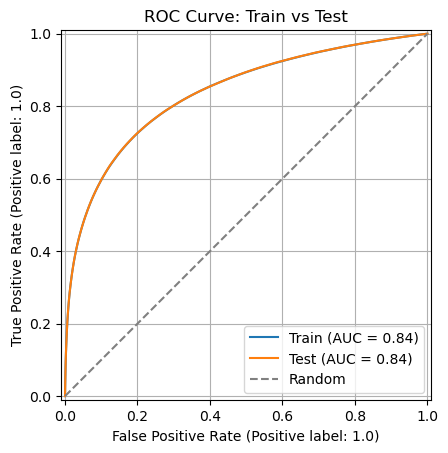

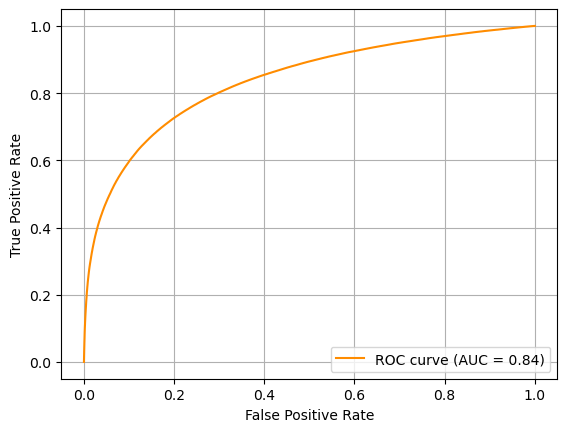

In [22]:
# Using Both Raw and Derived Features

RawNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi", 
            "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]

# Combine raw and feature-based variables
FeatureNames = list(set(VarNames[1:]) - set(RawNames))
Raw_FeatureNames = RawNames + FeatureNames
print("Using Combined Inputs:", Raw_FeatureNames[1:])

# Train/Test split
N_Train = 4000000
Train_Sample = df.loc[:N_Train, Raw_FeatureNames]
Test_Sample = df.loc[N_Train:, Raw_FeatureNames]

# Define inputs/labels
X_Train = Train_Sample[Raw_FeatureNames[1:]]
y_Train = Train_Sample["signal"]
X_Test = Test_Sample[Raw_FeatureNames[1:]]
y_Test = Test_Sample["signal"]

# Train the model
Fisher.fit(X_Train, y_Train)
Fisher_predict = Fisher.predict(X_Test)

# Accuracy and confusion matrix
print("Train Accuracy:", Fisher.score(X_Train, y_Train))
print("Test Accuracy:", Fisher.score(X_Test, y_Test))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_Test, Fisher_predict))
print()

# Evaluation
print_scores(Fisher)

# ROC curve
fpr3, tpr3, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
roc_auc3 = auc(fpr3, tpr3)

plt.plot(fpr3, tpr3, color='darkorange', label=f'ROC curve (AUC = {roc_auc3:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

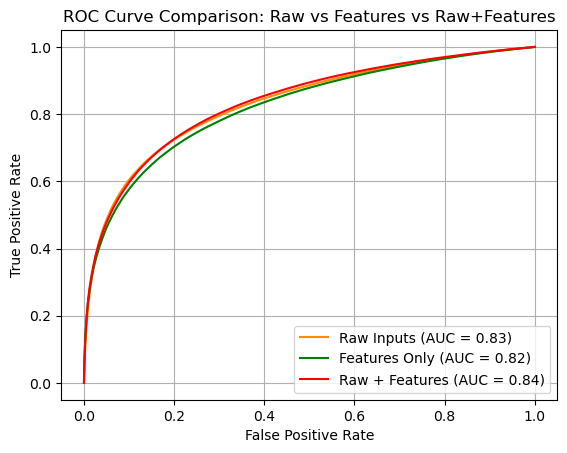

In [23]:
#Plotting the performance of all 3 models (Raw, Features, Raw+Features) on a single ROC plot

# Plotting ROC curves for:
# - Raw inputs
# - Derived features
# - Raw + features

plt.plot(fpr, tpr, color='darkorange', label=f'Raw Inputs (AUC = {roc_auc:.2f})')
plt.plot(fpr2, tpr2, color='green', label=f'Features Only (AUC = {roc_auc2:.2f})')
plt.plot(fpr3, tpr3, color='red', label=f'Raw + Features (AUC = {roc_auc3:.2f})')

# Labels, title, legend, and grid for clarity
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Raw vs Features vs Raw+Features')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [7]:
filename = "SUSY-small copy.csv"

VarNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta",
            "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", 
            "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames, nrows=10000)

LogisticRegression AUC: 0.858
RidgeClassifier AUC: 0.835
LinearSVC AUC: 0.856


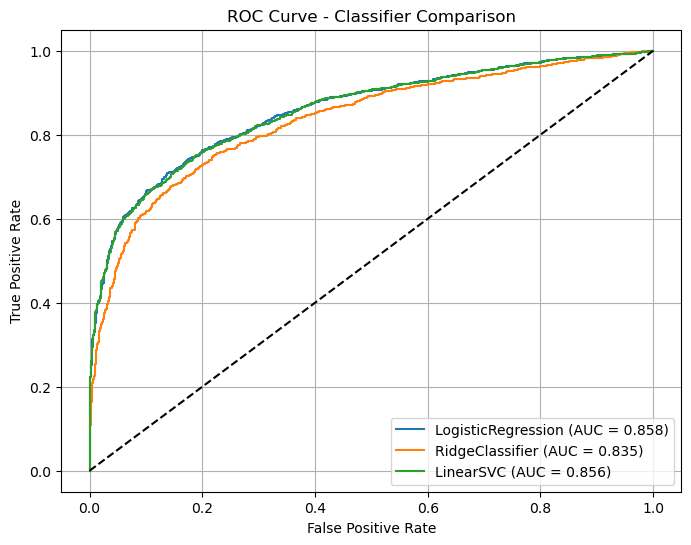

In [17]:
#part A: Comparing classifiers 
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Defining features and target
X = df.iloc[:, 1:]
y = df["signal"]

# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Classifiers
classifiers = [
    LogisticRegression(max_iter=1000),
    RidgeClassifier(),
    LinearSVC(dual="auto", max_iter=1000)
]

best_auc = 0
best_clf = None
best_scores = None

# Plotting ROC
plt.figure(figsize=(8, 6))

for clf in classifiers:
    clf.fit(X_train, y_train)
    
    # Getting decision scores
    if hasattr(clf, "decision_function"):
        y_scores = clf.decision_function(X_test)
    else:
        y_scores = clf.predict_proba(X_test)[:, 1]
    
    # Computing ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    print(clf.__class__.__name__, "AUC:", round(roc_auc, 3))

    # Update best
    if roc_auc > best_auc:
        best_auc = roc_auc
        best_clf = clf
        best_scores = y_scores

    plt.plot(fpr, tpr, label=f"{clf.__class__.__name__} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Classifier Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [19]:
#part B: Showcasing the best model
print("Best Classifier:", best_clf.__class__.__name__)
print("Best ROC AUC:", round(best_auc, 3))

Best Classifier: LogisticRegression
Best ROC AUC: 0.858


In [21]:
#part C: Computing Maximal Significance
y_pred = (best_scores > 0.5).astype(int)

N_S = ((y_pred == 1) & (y_test == 1)).sum()
N_B = ((y_pred == 1) & (y_test == 0)).sum()

sigma_s = N_S / np.sqrt(N_S + N_B) if (N_S + N_B) > 0 else 0
print("Maximal Significance (σₛ):", round(sigma_s, 2))

Maximal Significance (σₛ): 27.34


(IGNORE IF NEEDED)

Best Classifier Summary:

The best-performing model is identified based on the highest AUC value.  
The model is then used to compute the maximal significance using the formula:  
σₛ = Nₛ / √(Nₛ + Nᵦ), where Nₛ = true positives, Nᵦ = false positives.

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

(IGNORE IF NEEDED)

Some comments for Exercise 5:

In this exercise, we evaluate the best classifier from Exercise 4 using the following metrics:
- TPR (Recall)
- FPR
- ROC AUC
- Precision
- F1 Score
- Accuracy
- Maximal Significance

The metrics are summarized in a table for easy comparison.


In [23]:
# Metrics Summary for Best Classifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Threshold predictions from best classifier scores
y_pred = (best_scores > 0.5).astype(int)

# Computing metrics
TPR = recall_score(y_test, y_pred)
FPR = ((y_pred == 1) & (y_test == 0)).sum() / (y_test == 0).sum()
roc_auc_val = best_auc
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Maximal significance again for completeness
N_S = ((y_pred == 1) & (y_test == 1)).sum()
N_B = ((y_pred == 1) & (y_test == 0)).sum()
sigma_s = N_S / np.sqrt(N_S + N_B) if (N_S + N_B) > 0 else 0

# Tabulating results
import pandas as pd
metrics_table = pd.DataFrame({
    "Metric": ["TPR", "FPR", "ROC AUC", "Precision", "Recall", "F1 Score", "Accuracy", "Maximal Significance"],
    "Value": [TPR, FPR, roc_auc_val, precision, TPR, f1, accuracy, sigma_s]
})

# Display
print(metrics_table)

                 Metric      Value
0                   TPR   0.604920
1                   FPR   0.061187
2               ROC AUC   0.857594
3             Precision   0.894118
4                Recall   0.604920
5              F1 Score   0.721623
6              Accuracy   0.785000
7  Maximal Significance  27.340123
